### Types of Target Variables
| Type       | Examples        | ML Type        |
| ---------- | --------------- | -------------- |
| Binary     | Yes/No, 0/1     | Classification |
| Multiclass | Low/Medium/High | Classification |
| Continuous | Price, Score    | Regression     |

### Classification Target Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "age": np.random.randint(18, 65, 500),
    "income": np.random.normal(60000, 15000, 500),
    "purchased": np.random.choice([0, 1], p=[0.8, 0.2], size=500)
})
df.head()

,age,income,purchased
0,56,91995.500620,1
1,46,30718.683007,0
2,32,57723.223574,0
3,60,68824.758097,1
4,25,64214.878016,0


#### Class Distribution

In [3]:
df["purchased"].value_counts(normalize=True)

purchased
0    0.778
1    0.222
Name: proportion, dtype: float64

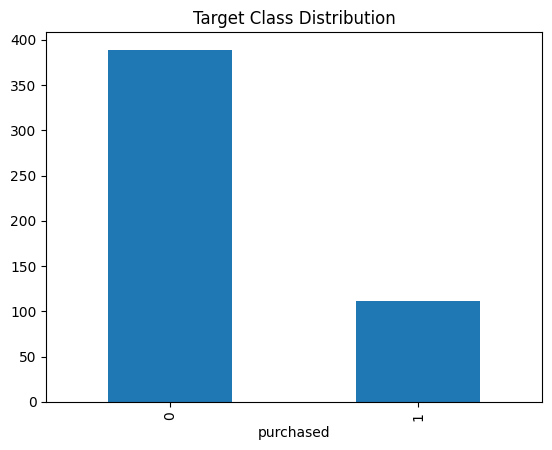

In [4]:
df["purchased"].value_counts().plot(kind="bar", title="Target Class Distribution")
plt.show()

**ML Impact:**
| Observation       | Impact                               |
| ----------------- | ------------------------------------ |
| Balanced          | Accuracy OK                          |
| Imbalanced        | Accuracy misleading                  |
| Extreme imbalance | Resampling / cost-sensitive learning |

#### Baseline Accuracy

In [5]:
df["purchased"].value_counts(normalize=True).max()

np.float64(0.778)

#### Feature <-> Target Separability

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

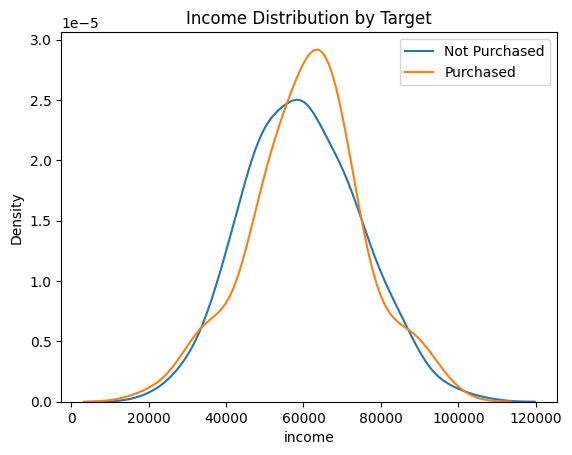

In [8]:
sns.kdeplot(df[df["purchased"] == 0]["income"], label="Not Purchased")
sns.kdeplot(df[df["purchased"] == 1]["income"], label="Purchased")
plt.legend()
plt.title("Income Distribution by Target")
plt.show()

**Interpretation:**
- Strong separation -> easier classification
- Heavy overlap -> complex model required

### Regression Target Analysis

In [10]:
df_reg = pd.DataFrame({
    "price": np.random.exponential(scale=100000, size=500)
})

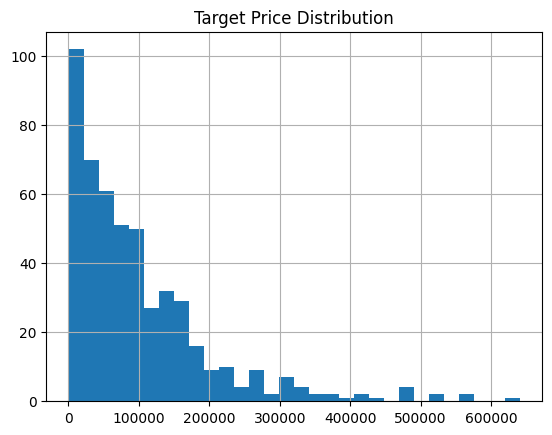

In [11]:
df_reg["price"].hist(bins=30)
plt.title("Target Price Distribution")
plt.show()

**ML Insight:**
- Right-skewed target -> Linear Regression struggles
- COnsider log-transform

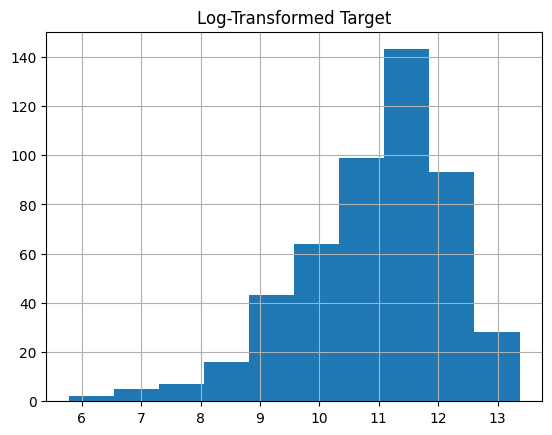

In [12]:
np.log1p(df_reg["price"]).hist()
plt.title("Log-Transformed Target")
plt.show()

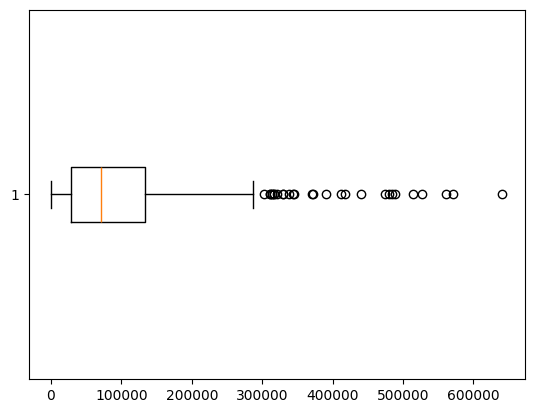

In [13]:
plt.boxplot(df_reg["price"], vert=False)
plt.show()

### Evalutation Metric Choice
| Target Shape      | Recommended Metrics |
| ----------------- | ------------------- |
| Symmetric         | MSE, RMSE           |
| Skewed            | MAE                 |
| Business critical | Custom loss         |